# DX799 Data Science Capstone — Module C, Milestone Two
**Sean Amisano — Boston University, Faculty of Computing & Data Sciences**

## Datasets

| Dataset | Rows | Used for |
|---|---|---|
| Breast Cancer Wisconsin (Diagnostic) | 569 × 30 | malignancy classification, mean-radius regression |
| UCI Heart Disease (Cleveland) | 303 × 13 | disease classification, cholesterol regression |
| Cancer Data Brazil (RCBP registry) | 1,778,176 × 38 | mortality classification at scale |

Every model in these notebooks is scored on a held-out 25% test split created with a
single fixed random state, and every hyperparameter is chosen by 5-fold cross-validation
on the training portion alone.

---
# Week 11 — DBSCAN and hierarchical agglomerative clustering  *(depth topic 2 of 2)*

K-Means makes two assumptions: k is known, and every point belongs to a cluster. Both
algorithms this week drop them.

**DBSCAN** replaces k with a density threshold (`eps`, `min_samples`), discovers the number
of clusters itself, finds arbitrarily shaped clusters, and labels low-density points as
noise. **Hierarchical agglomerative clustering** builds the full merge tree bottom-up; k is
chosen afterwards by cutting the tree at a height.

The question: on data where the true grouping is known, does relaxing K-Means'
assumptions buy anything?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from common import *
print('Random state:', RANDOM_STATE, '| test size:', TEST_SIZE, '| folds:', N_FOLDS)

Random state: 42 | test size: 0.25 | folds: 5


In [2]:
from sklearn.preprocessing import StandardScaler
bc, ht = load_bc(), load_heart()
Xs_b = StandardScaler().fit_transform(bc['X'])
Xs_h = StandardScaler().fit_transform(ht['X'])
y_b, y_h = bc['y_clf'].values, ht['y_clf'].values

## 1. Choosing eps properly

The recommended procedure: sort every point by the distance to its `min_samples`-th nearest
neighbour and take the knee. Points inside a cluster have a small such distance; noise
points have a large one, so the knee is the density threshold separating them.

In [3]:
from week11_dbscan_hac import k_distance
kd_b, eps_b, knee_b = k_distance(Xs_b, 10, 'bc')

[resume] loaded 17 existing keys from week11_dbscan_hac.json

--- bc: k-distance knee (min_samples=10) ---
  suggested eps = 4.6502 at index 507 of 569


The knee suggests eps ≈ 4.65. Hold on to that number — the grid search below finds
something quite different.

## 2. The (eps, min_samples) grid

Silhouette is computed on non-noise points only; including noise would penalise DBSCAN for
doing precisely what it was designed to do.

In [4]:
from week11_dbscan_hac import dbscan_grid
grid_b, best_b = dbscan_grid(Xs_b, y_b, 'bc',
                             eps_list=np.round(np.linspace(eps_b*0.5, eps_b*1.8, 8), 3),
                             ms_list=[5, 10, 20])


--- bc: DBSCAN grid (from saved record) ---
   ARI    NMI    eps  min_samples  n_clusters  noise_frac  silhouette_core
0.1649 0.1319 2.3250            5           2      0.4710           0.3351
0.0999 0.0561 3.1890            5           1      0.1793              NaN
0.0307 0.0142 4.0520            5           1      0.0773              NaN
0.0186 0.0096 4.9160            5           1      0.0422              NaN
0.0200 0.0199 5.7800            5           1      0.0228              NaN
0.0166 0.0183 6.6430            5           1      0.0176              NaN
0.0091 0.0082 7.5070            5           1      0.0123              NaN
0.0058 0.0059 8.3700            5           1      0.0070              NaN
0.2217 0.2549 2.3250           10           2      0.5554           0.3564
0.1301 0.0775 3.1890           10           1      0.2039              NaN
0.0463 0.0252 4.0520           10           1      0.0914              NaN
0.0210 0.0116 4.9160           10           1      0.04

**The k-distance heuristic overshoots badly here.** It recommends 4.65; the best ARI occurs
at eps = 2.325, half that. At the recommended eps, DBSCAN returns a single cluster
containing almost everything.

The reason is that the heuristic assumes a clear density gap between cluster interiors and
noise. In 30 standardised dimensions there is no such gap — the k-distance curve rises
smoothly, and the "knee" the algorithm finds is an artefact of curvature rather than a real
density boundary. This is the curse of dimensionality expressing itself in a density
estimate.

Even at its best setting, DBSCAN reaches ARI 0.165 while labelling 47.1% of patients as
noise, and its second cluster contains 4 points. This is not a usable clustering.

## 3. Linkage: the parameter that decides everything

- **single** — distance between the two closest members; prone to chaining.
- **complete** — distance between the two furthest members; compact, outlier-sensitive.
- **average** — mean pairwise distance.
- **ward** — merges the pair minimising the increase in within-cluster variance; the direct
  hierarchical analogue of the K-Means objective.

The **cophenetic correlation** measures how faithfully the dendrogram's merge heights
reproduce the original pairwise distances — a goodness-of-fit statistic for the tree itself,
independent of where it is cut.

In [5]:
from week11_dbscan_hac import hac_linkages
hac_b, trees_b = hac_linkages(Xs_b, y_b, 'bc', k=2)


--- bc: linkage comparison at k=2 (from saved record) ---
   ARI    NMI  cophenetic_corr  largest_cluster_frac  linkage  silhouette
0.5750 0.4569           0.5862                0.6766     ward      0.3394
0.0073 0.0151           0.8411                0.9947  average      0.6340
0.0048 0.0102           0.7928                0.9965   single      0.6607
0.0048 0.0102           0.6746                0.9965 complete      0.6607


### The central result of this notebook

| linkage | ARI | silhouette | cophenetic | largest cluster |
|---|---|---|---|---|
| ward | **0.575** | 0.339 | 0.586 | 67.7% |
| average | 0.007 | 0.634 | **0.841** | 99.5% |
| single | 0.005 | **0.661** | 0.793 | 99.6% |
| complete | 0.005 | **0.661** | 0.675 | 99.6% |

Ward is the only linkage that recovers the diagnosis. The other three put 99.5% of patients
in one cluster and the remaining handful in the other — a degenerate solution.

**And every internal metric prefers the degenerate solution.** Single linkage earns a
silhouette of 0.661 against Ward's 0.339; average linkage earns the best cophenetic
correlation, 0.841. If a practitioner had selected linkage by internal validation — which is
what one does when no labels exist — they would have chosen a clustering with an ARI of
0.005 and been given high confidence scores for it.

Silhouette is high because with 567 of 569 patients in one cluster and 2 in the other,
almost every point's nearest neighbours are in its own cluster, so `a` is tiny and `b` is
large for the two outliers and undefined-in-spirit for everyone else. The
metric is behaving exactly as defined; the definition simply does not encode "clusters
should be a useful size."

## 4. One tree, many cuts

In [6]:
from week11_dbscan_hac import hac_cut_sweep
Z_b, cuts_b = hac_cut_sweep(Xs_b, y_b, 'bc')


--- bc: ward-linkage cut sweep ---
 k    ARI  silhouette
 2 0.5750      0.3394
 3 0.5363      0.3301
 4 0.5434      0.2982
 5 0.5038      0.2434
 6 0.2865      0.1199
 7 0.2852      0.1238
 8 0.3099      0.0962
 9 0.2848      0.0999
10 0.2813      0.1032


This is HAC's practical advantage: the expensive linkage computation runs once and every k
is then free. ARI degrades gracefully from 0.575 at k=2 to 0.504 at k=5 before collapsing at
k=6 — the tree's top-level structure is genuinely two-part.

## 5. Three algorithms, identical data

In [7]:
from week11_dbscan_hac import three_way
km_b, db_b, hc_b, tw_b = three_way(Xs_b, y_b, 'bc',
                                   float(best_b['eps']), int(best_b['min_samples']))


--- bc: three-way clustering comparison ---
          n_clusters  noise_frac    ARI    NMI
KMeans        2.0000      0.0000 0.6707 0.5546
DBSCAN        2.0000      0.4710 0.1649 0.1319
Ward HAC      2.0000      0.0000 0.5750 0.4569


In [8]:
kd_h, eps_h, _ = k_distance(Xs_h, 10, 'heart')
grid_h, best_h = dbscan_grid(Xs_h, y_h, 'heart',
                             eps_list=np.round(np.linspace(eps_h*0.5, eps_h*1.8, 8), 3),
                             ms_list=[5, 10, 20])
hac_h, _ = hac_linkages(Xs_h, y_h, 'heart', k=2)
three_way(Xs_h, y_h, 'heart', float(best_h['eps']), int(best_h['min_samples']))


--- heart: k-distance knee (min_samples=10) ---
  suggested eps = 3.8357 at index 264 of 303

--- heart: DBSCAN grid (from saved record) ---
    ARI    NMI    eps  min_samples  n_clusters  noise_frac  silhouette_core
 0.0137 0.1292 1.9180            5           6      0.7393           0.2672
 0.0319 0.0210 2.6300            5           2      0.3465           0.1111
 0.0097 0.0125 3.3430            5           1      0.0594              NaN
 0.0043 0.0109 4.0550            5           1      0.0165              NaN
 0.0000 0.0000 4.7670            5           1      0.0000              NaN
 0.0000 0.0000 5.4800            5           1      0.0000              NaN
 0.0000 0.0000 6.1920            5           1      0.0000              NaN
 0.0000 0.0000 6.9040            5           1      0.0000              NaN
-0.0061 0.0414 1.9180           10           1      0.9241              NaN
 0.0649 0.0478 2.6300           10           1      0.4620              NaN
 0.0203 0.0198 3.3430 


--- heart: three-way clustering comparison ---
          n_clusters  noise_frac    ARI    NMI
KMeans        2.0000      0.0000 0.3868 0.3234
DBSCAN        2.0000      0.3465 0.0319 0.0210
Ward HAC      2.0000      0.0000 0.2455 0.1979


(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
        1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 

K-Means 0.671 > Ward 0.575 > DBSCAN 0.165 on breast cancer, and the same ordering holds on
heart disease. The extra generality of DBSCAN and HAC bought nothing here — because the
breast-cancer clusters really are convex, roughly equal-variance blobs, which is precisely
the case K-Means is built for. Flexibility costs performance when the simpler model's
assumptions happen to hold.

## 6. The registry

In [9]:
from week11_dbscan_hac import brazil_density
bz = brazil_density()


--- Brazil registry: density clustering on 8,000 rows (from saved record) ---
    ARI    NMI    eps  min_samples  n_clusters  noise_frac  silhouette_core
-0.0463 0.0713 0.7070            5          95      0.8146           0.4423
-0.0460 0.0710 1.0180            5         134      0.7629           0.3980
-0.0431 0.0677 1.3290            5         168      0.7256           0.3685
 0.0949 0.0503 1.6400            5          17      0.2536          -0.1238
 0.0734 0.0446 1.9520            5           7      0.1610          -0.1018
 0.0136 0.0148 2.2630            5           1      0.0209              NaN
-0.0408 0.0623 0.7070           10          30      0.8884           0.4677
-0.0426 0.0617 1.0180           10          41      0.8514           0.4183
-0.0434 0.0615 1.3290           10          57      0.8233           0.3909
 0.0934 0.0680 1.6400           10           9      0.3499          -0.0478
 0.0987 0.0614 1.9520           10           4      0.2333           0.0242
 0.0200 0

HAC is O(n²) in memory, capping the sample at 8,000 rows out of 141,452 — a real
scalability limit worth stating. On one-hot encoded categorical data, density-based
clustering has a further problem: identical category combinations sit at distance zero and
everything else sits at one of a small number of discrete distances, so the density
landscape is a set of spikes rather than a continuum. All three algorithms return ARI below
0.10.

## Figure

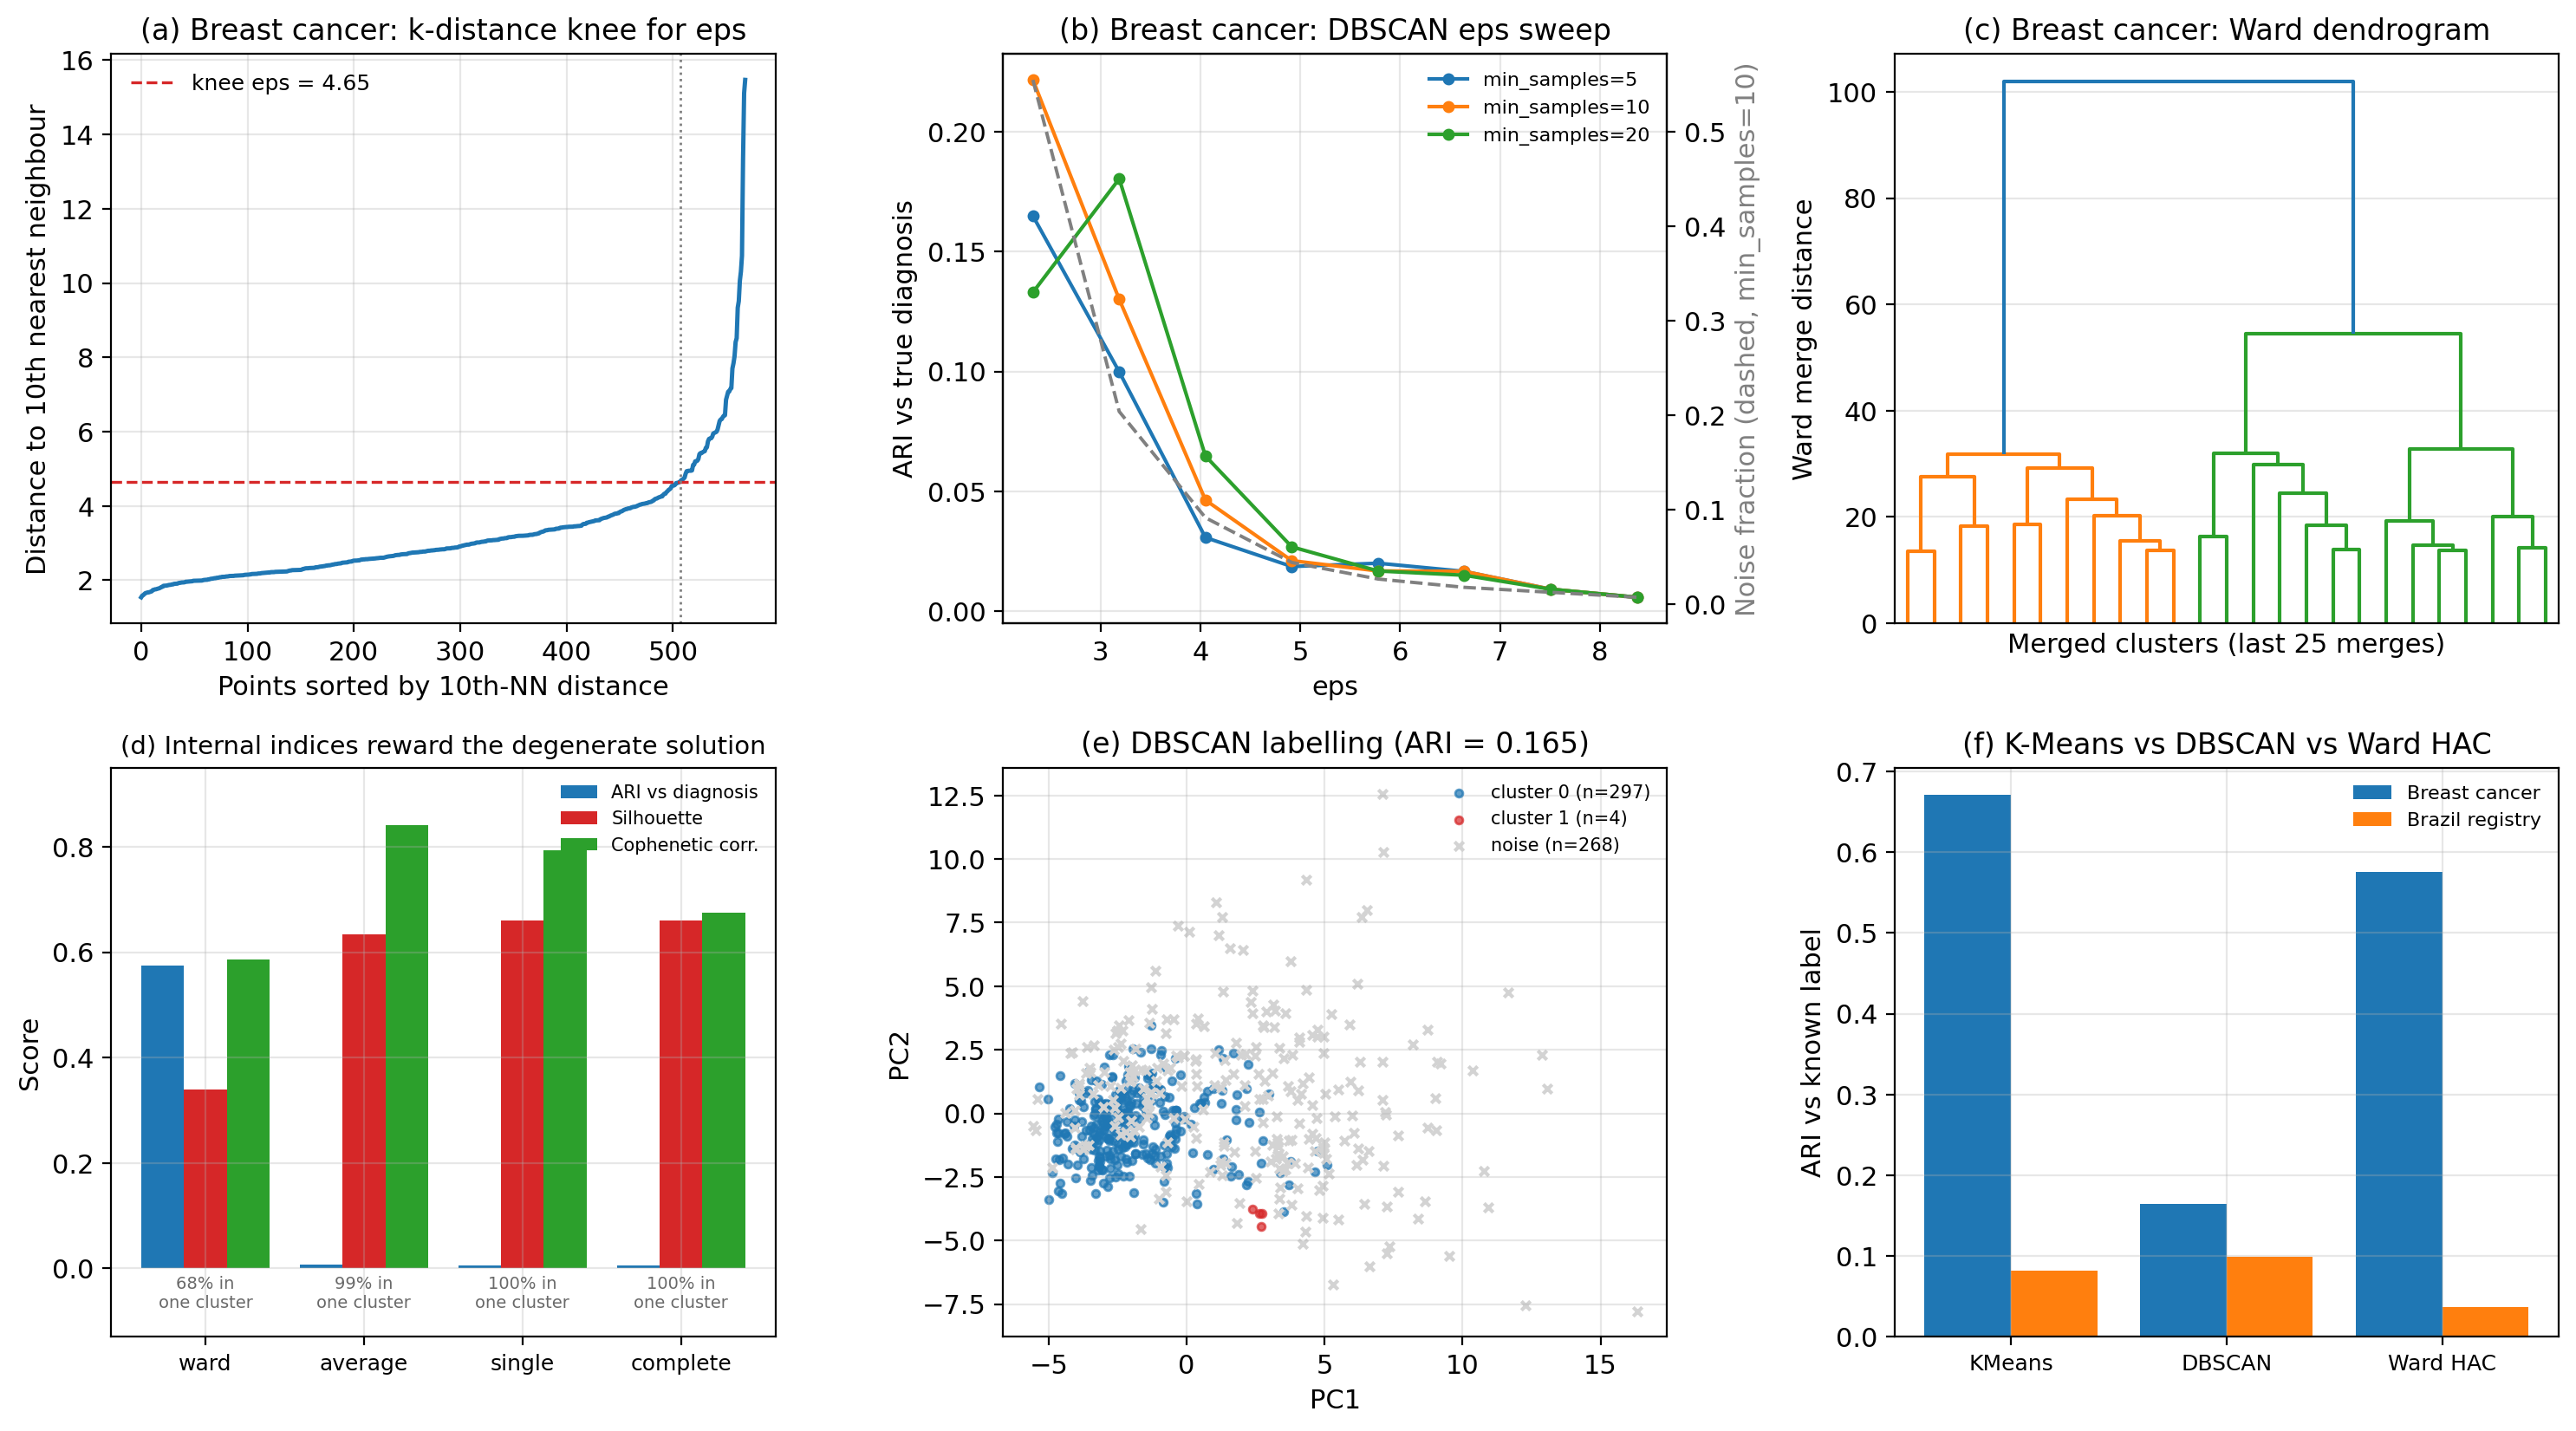

In [10]:
from IPython.display import Image
Image('../figures/fig_week11_dbscan_hac.png')

## Week 11 conclusions

- The k-distance heuristic for eps overshot by a factor of two on 30-dimensional data.
  Principled defaults still need validating.
- Linkage choice moved ARI from 0.005 to 0.575 — a larger effect than any hyperparameter
  in any other week of this project.
- **Internal validation indices actively preferred a degenerate clustering.** Silhouette
  and cophenetic correlation both ranked the worst clusterings highest. This is the single
  most important methodological caution in Milestone Two.
- DBSCAN's noise label is genuinely useful as a diagnostic — 47% noise is the algorithm
  reporting that this data has no density structure — even when its clustering is not.